Task 4: Predicting Insurance Claim Amounts

Data Loading and Preparation

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Download the Medical Cost Personal Dataset [cite: 58]
path = kagglehub.dataset_download("mirichoi0218/insurance")
file_path = os.path.join(path, "insurance.csv")

df = pd.read_csv(file_path)

# Display basic structure [cite: 84]
print("Dataset Shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'insurance' dataset.
Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Data Cleaning and Encoding

In [12]:
# Convert binary categorical variables to 0 and 1
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# One-hot encode the 'region' column
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("Data preparation complete. Numerical columns only.")

Data preparation complete. Numerical columns only.


Exploratory Data Analysis (EDA)

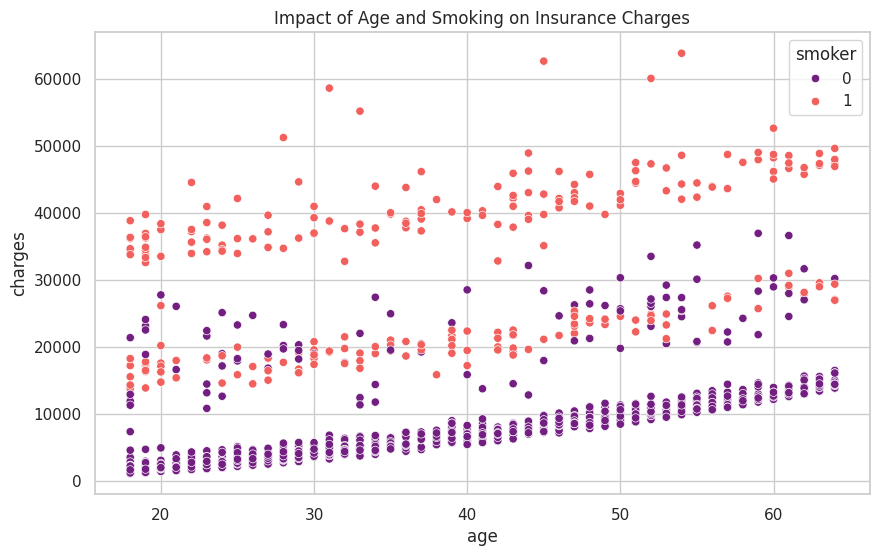

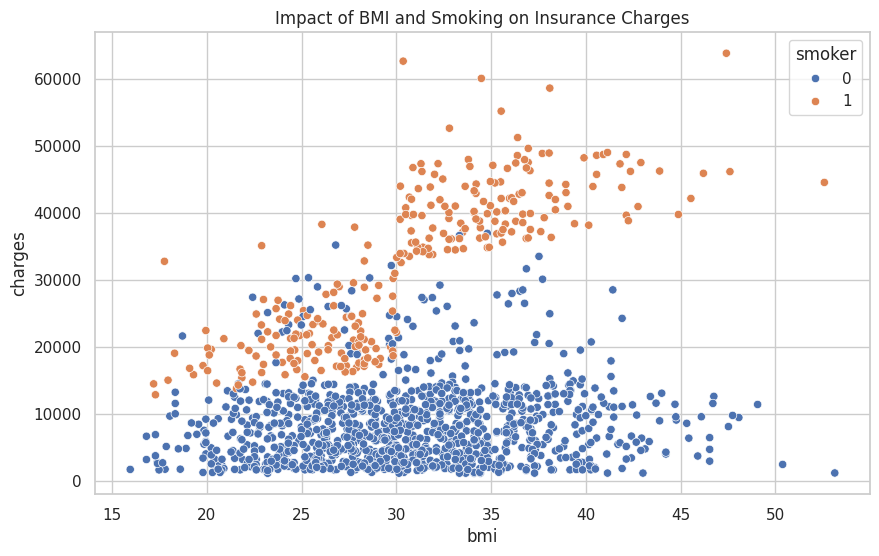

In [13]:
# Set visual style
sns.set(style="whitegrid")

# 1. Age vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', palette='magma')
plt.title('Impact of Age and Smoking on Insurance Charges')
plt.show()

# 2. BMI vs Charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker')
plt.title('Impact of BMI and Smoking on Insurance Charges')
plt.show()

Model Training and Evaluation

In [14]:
# Define Features (X) and Target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model [cite: 60]
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics [cite: 62, 88]
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 4181.19
Root Mean Squared Error (RMSE): 5796.28


Task 5: Personal Loan Acceptance Prediction

Data Loading and Exploration

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Download the Bank Marketing Dataset [cite: 71]
path = kagglehub.dataset_download("gatunnopvp/bank-marketing-campaigh-dataset")

# Directly specify the correct CSV file path found in the previous execution
file_path = os.path.join(path, "bank-full.csv")

print(f"Found CSV file at: {file_path}")

# This specific dataset often uses semicolons (;) as delimiters
df = pd.read_csv(file_path, sep=';')

# Basic data exploration [cite: 73, 77]
print("Dataset Shape:", df.shape)
display(df.head())

Using Colab cache for faster access to the 'bank-marketing-campaigh-dataset' dataset.
Found CSV file at: /kaggle/input/bank-marketing-campaigh-dataset/bank-full.csv
Dataset Shape: (45210, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,durations,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


Exploratory Data Analysis (EDA)

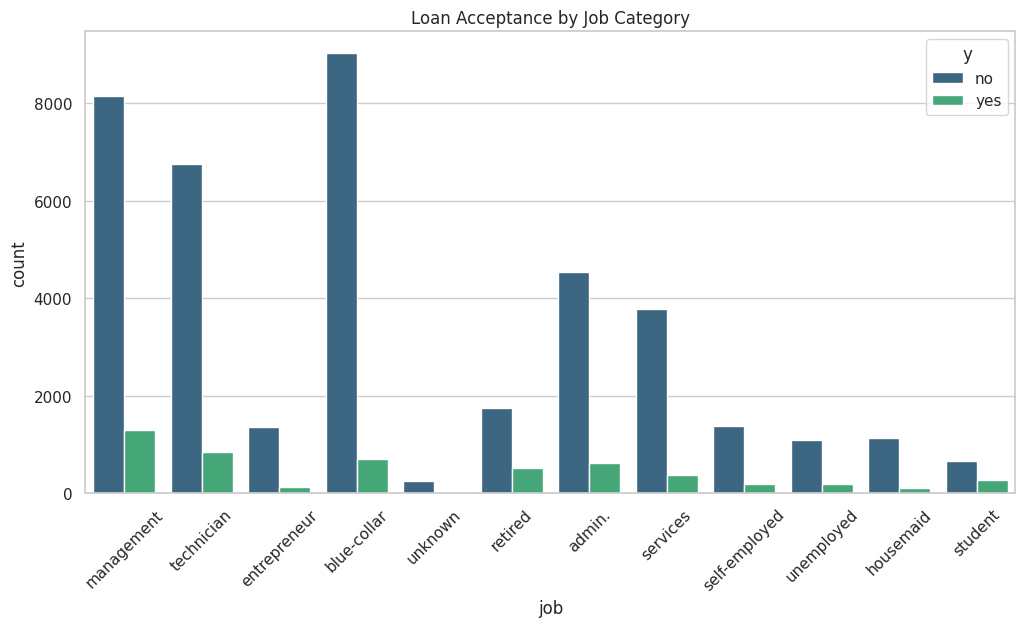

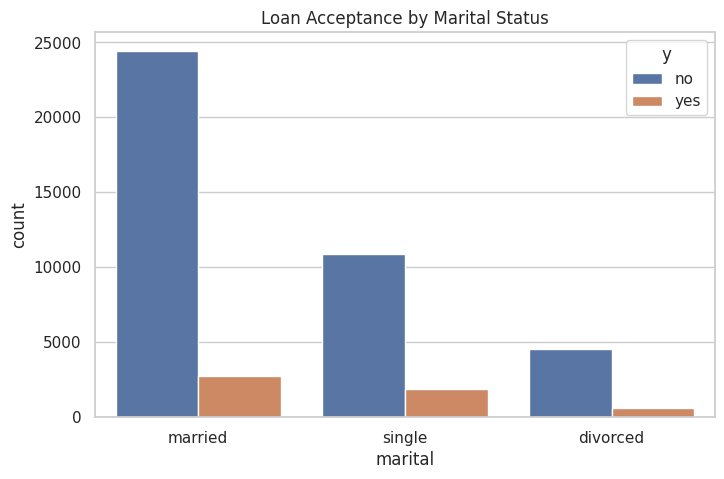

In [16]:
sns.set(style="whitegrid")

# 1. Job vs Loan Acceptance (y)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='job', hue='y', palette='viridis')
plt.xticks(rotation=45)
plt.title('Loan Acceptance by Job Category')
plt.show()

# 2. Marital Status vs Loan Acceptance
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='marital', hue='y')
plt.title('Loan Acceptance by Marital Status')
plt.show()

Classification Modeling

In [17]:
#We will use a Decision Tree Classifier to predict acceptance.
# Encoding target variable 'y' to 1 (yes) and 0 (no)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Select key features and encode them [cite: 73, 74]
features = ['age', 'job', 'marital', 'education', 'housing', 'loan', 'campaign']
X = pd.get_dummies(df[features], drop_first=True)
y = df['y']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree [cite: 74]
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predictions & Evaluation
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94      7949
           1       0.83      0.00      0.01      1093

    accuracy                           0.88      9042
   macro avg       0.86      0.50      0.47      9042
weighted avg       0.87      0.88      0.82      9042

